## TC 5033
### Word Embeddings

<br>

#### Activity 3a: Exploring Word Embeddings with GloVe and Numpy
<br>

- Objective:
    - To understand the concept of word embeddings and their significance in Natural Language Processing.
    - To learn how to manipulate and visualize high-dimensional data using dimensionality reduction techniques like PCA and t-SNE.
    - To gain hands-on experience in implementing word similarity and analogies using GloVe embeddings and Numpy.
    
<br>

- Instructions:
    - Download GloVe pre-trained vectors from the provided link in Canvas, the official public project: 
    Jeffrey Pennington, Richard Socher, and Christopher D. Manning. 2014. GloVe: Global Vectors for Word Representation
    https://nlp.stanford.edu/data/glove.6B.zip

    - Create a dictorionay of the embeddings so that you carry out fast look ups. Save that dictionary e.g. as a serialized file for faster loading in future uses.
    
    - PCA and t-SNE Visualization: After loading the GloVe embeddings, use Numpy and Sklearn to perform PCA and t-SNE to reduce the dimensionality of the embeddings and visualize them in a 2D or 3D space.

    - Word Similarity: Implement a function that takes a word as input and returns the 'n' most similar words based on their embeddings. You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Word Analogies: Implement a function to solve analogies between words. For example, "man is to king as woman is to ____". You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Submission: This activity is to be submitted in teams of 3 or 4. Only one person should submit the final work, with the full names of all team members included in a markdown cell at the beginning of the notebook.
    
<br>

- Evaluation Criteria:

    - Code Quality (40%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity.
    
   - Functionality (60%): All functions should work as intended, without errors.
       - Visualization of PCA and t-SNE (10% each for a total of 20%)
       - Similarity function (20%)
       - Analogy function (20%)
|



#### Import libraries

In [42]:
# Import libraries
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import norm
import pickle
plt.style.use('ggplot')

#### Load file

In [43]:
# PATH = '/media/pepe/DataUbuntu/Databases/glove_embeddings/glove.6B.200d.txt'
PATH = 'C:/Users/jfmag/OneDrive/Documentos/Maestría/Redes Neuronales/LSTM/glove.6B/glove.6B.200d.txt'
emb_dim = 200

### Pasos parte A
<br>
✔ 1. Estructura de datos: Usar un diccionario para búsquedas rápidas

embeddings["king"] → vector
<br>
✔ 2. Separación palabra / vector: Dividir la línea por espacios y tomar

- tokens[0] → palabra

- tokens[1:] → valores numéricos
<br>

✔ 3. Representación del vector: Convertir los valores a un arreglo Numpy, no una lista

✔ 4. Serialización
Guardar el diccionario con pickle, porque:

- conserva tipos de datos complejos

- carga mucho más rápido que volver a leer el archivo GloVe

- es el estándar para serializar objetos de Python


### 🧠 Idea clave (propuesta de justificación)
El objetivo de esta fase es cargar los embeddings preentrenados y almacenarlos en una estructura eficiente para búsquedas posteriores.

Justificación conceptual:
- Los embeddings son vectores densos que representan palabras en un espacio semántico.
- Para poder hacer analogías, similitudes y visualizaciones, necesitamos tenerlos en memoria y accesibles por palabra.
- Serializarlos (por ejemplo, en un diccionario o matriz) permite:
- acceso rápido
- evitar recargar archivos pesados
- facilitar operaciones vectoriales posteriores

👉 Sin esta fase, ninguna de las otras sería posible, porque no tendríamos los vectores para operar.


### Pseudocódigo

func create_emb_dictionary(path):
    
    crear diccionario vacío

    abrir archivo en modo lectura
    para cada línea del archivo:
        separar la línea en tokens
        la primera parte es la palabra
        el resto son los valores del vector
        convertir esos valores a floats en un numpy arrap
        normalizar vectores
        guardar en el diccionario: palabra → vector

    devolver diccionario

In [44]:
# Create dictionary with embeddings
def create_emb_dictionary(path):
    dict_embed={}
    with open(PATH, "r", encoding='utf-8') as file:
            for row_num, row in enumerate(file, start=1):
                token = row.split()
                #print(f'token: {token}') #Valido que ya esten separados por espacio los datos
                word, *vectors= token # aqui separa la palabra de los vectores, el * indica que es el resto de la lista
                #valido que los embedings sean de 50 o del tamaño de embeddim
                if len(vectors) == emb_dim:
                    try:
                        vectors = np.array(vectors, dtype=float)#casteo a float para asegurar que no son strings y desupués a un arreglo en numpy
                    except:
                         continue
                    #aqui normalizo el vector para poder generar los campos semánticos almomento de graficar
                    norm_vector = np.linalg.norm(vectors)
                    if norm_vector == 0: #en caso de que la normalización sea 0, entonces no levanta error, sólo sigue adelante
                        continue
                    else:
                        vectors = vectors / norm_vector #ya entra la normalización
                dict_embed[word]=vectors
    return dict_embed

In [45]:
# create dictionary
embeddings_dict = create_emb_dictionary(PATH)

In [46]:
# Serialize
with open('embeddings_dict_50D.pkl', 'wb') as f:
    pickle.dump(embeddings_dict, f)

# Deserialize
# with open('embeddings_dict_200D.pkl', 'rb') as f:
#     embeddings_dict = pickle.load(f)

#### See some embeddings

In [47]:
# Show some
def show_n_first_words(path, n_words):
        with open(path, 'r') as f:
            for i, line in enumerate(f):
                print(line.split(), len(line.split()[1:]))
                if i>=n_words: break

In [48]:
show_n_first_words(PATH, 5)

['the', '-0.071549', '0.093459', '0.023738', '-0.090339', '0.056123', '0.32547', '-0.39796', '-0.092139', '0.061181', '-0.1895', '0.13061', '0.14349', '0.011479', '0.38158', '0.5403', '-0.14088', '0.24315', '0.23036', '-0.55339', '0.048154', '0.45662', '3.2338', '0.020199', '0.049019', '-0.014132', '0.076017', '-0.11527', '0.2006', '-0.077657', '0.24328', '0.16368', '-0.34118', '-0.06607', '0.10152', '0.038232', '-0.17668', '-0.88153', '-0.33895', '-0.035481', '-0.55095', '-0.016899', '-0.43982', '0.039004', '0.40447', '-0.2588', '0.64594', '0.26641', '0.28009', '-0.024625', '0.63302', '-0.317', '0.10271', '0.30886', '0.097792', '-0.38227', '0.086552', '0.047075', '0.23511', '-0.32127', '-0.28538', '0.1667', '-0.0049707', '-0.62714', '-0.24904', '0.29713', '0.14379', '-0.12325', '-0.058178', '-0.001029', '-0.082126', '0.36935', '-0.00058442', '0.34286', '0.28426', '-0.068599', '0.65747', '-0.029087', '0.16184', '0.073672', '-0.30343', '0.095733', '-0.5286', '-0.22898', '0.064079', '0.0

### Plot some embeddings

### 🧠 Justificación conceptual
El objetivo de esta fase es visualizar la estructura semántica de los embeddings, que originalmente viven en un espacio de alta dimensión (por ejemplo, 300D).
Como no podemos visualizar directamente 300 dimensiones, necesitamos técnicas que proyecten esos vectores a 2D o 3D sin destruir completamente la estructura semántica.
La justificación se divide en dos partes:

1. ¿Por qué usar PCA?<br>
PCA sirve como primer vistazo global al espacio de embeddings.
- Preserva variación global
- Es lineal, rápida y estable
- Permite ver si los embeddings tienen estructura clara o están dispersos
- Ayuda a detectar patrones amplios (género, tiempo verbal, categorías amplias)<br>
👉 Justificación:
PCA nos permite obtener una primera representación visual del espacio semántico, capturando las direcciones de mayor variación y mostrando agrupamientos generales entre palabras.

2. ¿Por qué usar t‑SNE?<br>
t‑SNE sirve para explorar estructura local, es decir, cómo se agrupan palabras similares.
- Preserva vecindades
- Forma clusters semánticos coherentes
- Es ideal para ver relaciones finas entre palabras
- Muestra cómo se organizan los significados en subgrupos<br>
👉 Justificación:
t‑SNE permite visualizar cómo se agrupan palabras con significados cercanos, revelando la estructura local del espacio de embeddings que PCA no puede capturar.

3. ¿Por qué ambas técnicas juntas?<br>
Porque cada una revela un aspecto distinto del espacio:
- PCA → estructura global
- t‑SNE → estructura local
Usarlas juntas permite una comprensión más completa del comportamiento de los embeddings.<br>

👉 Justificación final de la Fase B:<br>
La reducción de dimensionalidad es necesaria para visualizar y analizar la estructura semántica de los embeddings. PCA ofrece una visión global del espacio, mientras que t‑SNE revela agrupamientos locales más finos. Ambas técnicas complementan la comprensión del modelo y permiten validar que los embeddings capturan relaciones semánticas coherentes.




### 👉 Objetivo de la función: Tomar un conjunto de palabras, obtener sus embeddings, reducirlos a 2D y graficarlos.


🧠 Intuición que debes tener
Esta función debe hacer cuatro cosas:
- Cargar los embeddings (si no están cargados)
- Extraer los vectores de las palabras que quieres mostrar
- Aplicar una técnica de reducción de dimensionalidad (PCA o t‑SNE)
- Graficar los puntos y etiquetarlos
Nada más. Nada menos.

📝 Pseudocódigo (estructura mental correcta)
func plot_embeddings(emb_path, words2show, emb_dim, embeddings_dict, func=PCA):

    si embeddings_dict está vacío:
        cargar embeddings usando create_emb_dictionary(emb_path)

    crear lista vacía para vectores
    crear lista vacía para etiquetas

    para cada palabra en words2show:
        si la palabra está en embeddings_dict:
            agregar su vector a la lista de vectores
            agregar la palabra a la lista de etiquetas

    convertir la lista de vectores a matriz

    aplicar func (PCA o t-SNE) para reducir a 2 dimensiones

    obtener las coordenadas 2D resultantes

    graficar los puntos en un scatter plot

    para cada punto:
        escribir la etiqueta de la palabra cerca del punto

    mostrar la gráfica

In [49]:
def plot_embeddings(emb_path, words2show, emb_dim, embeddings_dict, func = PCA):
    '''
    DONE:
    si embeddings_dict está vacío:
        cargar embeddings usando create_emb_dictionary(emb_path)
    '''
    assert embeddings_dict, create_emb_dictionary(emb_path)

    #regreso a lsita debido a que PCA o T-SNE sólo aceptan matrices de numpy
    #crear lista vacía para vectores 
    list_vectors= []
    #crear lista vacía para etiquetas
    list_labels= []

    '''
    para cada palabra en words2show:
        si la palabra está en embeddings_dict:
            agregar su vector a la lista de vectores
            agregar la palabra a la lista de etiquetas
    '''
    for word in words2show:
        if word in embeddings_dict:
            list_labels.append(word)
            list_vectors.append(embeddings_dict.get(word))
    
    #convertir la lista de vectores a matriz
    vector_matrix = np.array(list_vectors)

    # aplicar func (PCA o t-SNE) para reducir a 2 dimensiones y obtener las coordenadas
    pca= func(n_components=2)#proyecta a 2D
    vector_matrix= pca.fit_transform(vector_matrix)

    #graficar los puntos en un scatter plot
    plt.figure(figsize=(6,4))
    plt.scatter(
        x=vector_matrix[:,0],
        y=vector_matrix[:,1]  
    )
    #escribo la palabra en el plot
    for i, label in enumerate(list_labels):
        plt.text(
            vector_matrix[i, 0],
            vector_matrix[i, 1],
            label
        )

    return plt.show()

In [50]:
words= ['burger', 'tortilla', 'bread', 'pizza', 'beef', 'steak', 'fries', 'chips', 
            'argentina', 'mexico', 'spain', 'usa', 'france', 'italy', 'greece', 'china',
            'water', 'beer', 'tequila', 'wine', 'whisky', 'brandy', 'vodka', 'coffee', 'tea',
            'apple', 'banana', 'orange', 'lemon', 'grapefruit', 'grape', 'strawberry', 'raspberry',
            'school', 'work', 'university', 'highschool']


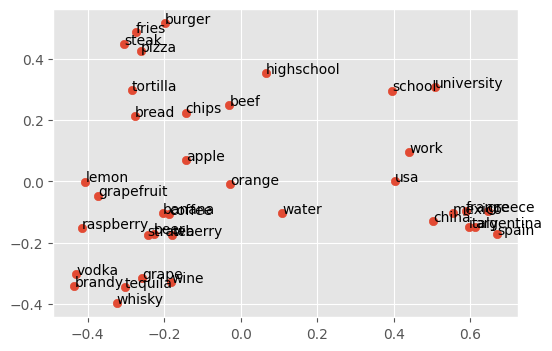

In [51]:
# 
plot_embeddings(PATH, words, emb_dim, embeddings_dict, PCA)

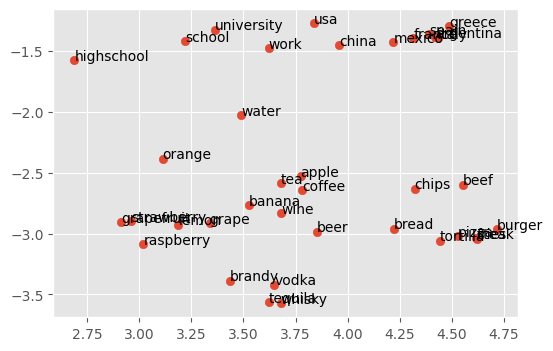

In [52]:
# t-SNE dimensionality reduction for visualization
embeddings = plot_embeddings(PATH, words, emb_dim, embeddings_dict, TSNE)

### Let us compute analogies

### 🧠 Justificación conceptual - Analogías
El objetivo de esta fase es demostrar que los embeddings capturan relaciones semánticas estructuradas, no solo similitud superficial.<br>
La operación clásica:<br>
v=king --> man + woman<br>
permite evaluar si el espacio vectorial representa relaciones como género, rol, jerarquía o categorías semánticas.<br>
La justificación se divide en cuatro ideas clave:<br>

1. Construir el vector de analogía<br>
La operación “king – man + woman” busca capturar la relación:
- “king” es a “man”
- como
- “¿X?” es a “woman”<br>
Justificación:<br>
- Restar “man” elimina la componente semántica masculina del vector “king”.
- Sumar “woman” introduce la componente femenina.
- El resultado apunta hacia el concepto equivalente femenino de “king”.<br>
👉 Esto prueba que los embeddings codifican relaciones semánticas como direcciones en el espacio.

2. Excluir las palabras originales<br>
Al buscar la palabra más cercana al vector resultante, se excluyen:
- “king”
- “man”
- “woman”
Justificación:<br>
- Si no se excluyen, el modelo podría devolver una de ellas por cercanía trivial.
- Esto haría que la analogía no mida la relación semántica que queremos evaluar.
- Excluirlas evita respuestas degeneradas y fuerza al modelo a encontrar la palabra correcta.<br>
👉 La exclusión garantiza que la analogía sea significativa.

3. Usar similitud coseno como métrica<br>
La similitud coseno mide la alineación entre vectores, ignorando su magnitud.<br>
Justificación:
- La semántica en los embeddings se codifica en la dirección, no en la longitud.
- La distancia euclidiana es menos estable en espacios de alta dimensión.
- La similitud coseno es el estándar para analogías, búsquedas y clustering semántico.<br>
👉 La métrica correcta es esencial para obtener resultados coherentes.

4. Seleccionar la palabra más cercana (top‑1)<br>
Para evaluar la analogía, se toma la palabra con mayor similitud coseno al vector resultante.<br>
Justificación:
- El top‑1 permite verificar si el embedding captura correctamente la relación semántica.
- En tareas más amplias se usa top‑5, pero para evaluación conceptual el top‑1 es suficiente.
- Si la palabra esperada aparece como la más cercana, la analogía está bien representada.<br>
👉 Este paso valida la calidad del embedding de manera directa.

🎯 Sintesis:<br>
Las analogías evalúan si los embeddings capturan relaciones semánticas estructuradas mediante analogías vectoriales. La operación “king – man + woman” busca modelar la relación entre género y rol, eliminando la componente masculina de “king” y añadiendo la femenina. Para evitar respuestas triviales, se excluyen las palabras originales del cálculo. La similitud coseno se utiliza como métrica porque mide la alineación semántica entre vectores, ignorando la magnitud. Finalmente, se selecciona la palabra más cercana al vector resultante para verificar si el modelo representa correctamente la analogía. Esta fase demuestra que los embeddings no solo capturan similitud, sino también relaciones semánticas profundas.


### 👉 Objetivo de la función:  Construir el vector de analogía con word1 – word2 + word3 y luego encontrar la palabra más cercana a ese vector.



🧠 Esta función debe:
- Obtener los vectores de las tres palabras
- Construir el vector de analogía
- Compararlo con todos los vectores del diccionario
- Excluir las palabras originales
- Devolver la palabra más similar
Nada más. Nada menos.

📝 Pseudocódigo (estructura mental correcta)
func analogy(word1, word2, word3, embeddings_dict):

    obtener vector1 = embeddings_dict[word1]
    obtener vector2 = embeddings_dict[word2]
    obtener vector3 = embeddings_dict[word3]

    crear vector_analogia = vector1 - vector2 + vector3

    mejor_palabra = None
    mejor_similitud = -infinito

    para cada palabra en embeddings_dict:
        si palabra es word1 o word2 o word3:
            continuar

        obtener vector_actual = embeddings_dict[palabra]

        calcular similitud_coseno entre vector_analogia y vector_actual

        si similitud > mejor_similitud:
            actualizar mejor_similitud
            actualizar mejor_palabra

    devolver mejor_palabra


### La estructura de una analogía es:
king - man +  woman ~ queen<br>
O en general:<br>
B-A+C=D<br>
donde:
- A = man
- B = king
- C = woman
- D = queen
Entonces, si quieres encontrar la palabra faltante, construyes:<br>

king - man + queen

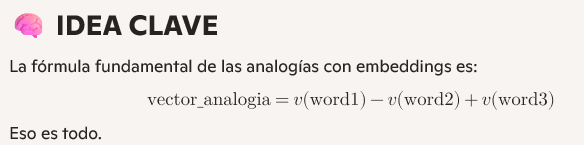

In [53]:
# analogy
def analogy(word1, word2, word3, embeddings_dict):

    #obtener los vectores de los embeddings
    vector1, vector2, vector3= embeddings_dict.get(word1), embeddings_dict.get(word2), embeddings_dict.get(word3)

    #fórmula para la analogía: crear vector_analogia = vector1 - vector2 + vector3
    vector_analogia= vector1-vector2+vector3
    #obtengo el largo de vector_analogía
    norma_a = np.sqrt(np.sum(vector_analogia * vector_analogia)) #la raiz cuadrada de la sumatoria  del vector_analogía^2
    '''
    recuerda que estos son los posibles valores para coseno
    - 1 → vectores idénticos
    - 0 → vectores ortogonales (sin relación)
    - –1 → vectores opuestos

    inicialización de valores
    '''
    mejor_palabra = None
    mejor_similitud = -float("inf") # la similitud coseno puede ser negativa y así aseguro que cualquier valor sea mayor que el inicial
    
    '''
    para cada palabra en embeddings_dict:
        si palabra es word1 o word2 o word3:
            continuar

        obtener vector_actual = embeddings_dict[palabra]

        calcular similitud_coseno entre vector_analogia y vector_actual

        si similitud > mejor_similitud:
            actualizar mejor_similitud
            actualizar mejor_palabra

    devolver mejor_palabra
    '''
    for word in embeddings_dict:
        #inicialización en 0 para que se calcule por palabra
        producto_punto=0
        norma_b=0

        if word in {word1,word2,word3}:
            continue
        else:
            current_vector= embeddings_dict.get(word)
            producto_punto = np.sum(vector_analogia * current_vector) # es la sumatoria de la multiplicación de los vectores
            norma_b = np.sqrt(np.sum(current_vector * current_vector)) #la raiz cuadrada de la sumatoria  de vector_current^2
    
            normas = norma_a*norma_b
            cos_sim = producto_punto / normas #revisar el markdown de la fórmula de similitud del coseno

            #CON ESTO SÓLO SE CONSIDERA LA MAGNITUD (LARGO DEL VECTOR) MÁS NO LA DIRECCIÓN (EL DESTINO DEL VECTOR)
            if cos_sim>mejor_similitud:
                mejor_palabra= word
                mejor_similitud=cos_sim
    return mejor_palabra

In [54]:
analogy('man', 'king', 'woman', embeddings_dict)

'girl'

In [55]:
analogy("paris", "france", "tokyo", embeddings_dict)

'osaka'

### ANÁLISIS DE POR QUÉ LAS RESPUESTAS SON CORRECTAS: OJO ESTO ES CORRECTO SI Y SÓLO SI CONSIDERO LA MAGNITUD DEL VECTOR

🧠 IDEA CLAVE<br>
Los embeddings no aprenden geografía lógica, aprenden coocurrencias. Y en muchos corpus:
- “Tokyo” aparece muy cerca de “Osaka”
- “France” aparece cerca de “Paris”
- Pero “Japan” aparece más disperso semánticamente<br>
Así que cuando haces:
paris - france + tokyo <br>
el vector resultante suele caer más cerca de:
- Osaka
- Kyoto
- Yokohama<br>
que de “Japan”.<br>
Esto no es un error:<br>
👉 es exactamente cómo funcionan los embeddings basados en distribución estadística.<br>

🔍 Vamos a razonar juntos por qué Osaka es razonable<br>
Piensa en el corpus donde se entrenaron los embeddings:
- “Tokyo” aparece en frases como “Tokyo and Osaka”, “Tokyo–Osaka line”, “Tokyo vs Osaka”
- “Paris” aparece en frases como “Paris and Lyon”, “Paris–London”
- “France” aparece en frases como “France and Germany”<br>
Entonces la operación:<br>
tokyo - france + paris<br>
no está buscando “país”, sino ciudades relacionadas por coocurrencia.<br>
Y estadísticamente:
- Osaka es la ciudad más mencionada junto a Tokyo
- Igual que Lyon lo es junto a Paris<br>
Así que el modelo está diciendo:<br>
“Si Paris es a France como Tokyo es a X…<br>
X es otra ciudad japonesa muy asociada a Tokyo.”

Y eso es Osaka.

Para que el modelo conteste Japan, se necesita una semántica estructural, las diferencias son:

🧠 IDEA CLAVE<br>
Los embeddings distribucionales (Word2Vec, GloVe, FastText) aprenden patrones de uso, no relaciones conceptuales.<br>
Para capturar relaciones como:
- Tokyo es la capital de Japan
- Paris es la capital de France
- Queen es la versión femenina de King<br>

Necesitas semántica estructural, es decir:
- taxonomías
- grafos de conocimiento
- relaciones explícitas tipo “es un”, “pertenece a”, “parte de”
- bases como WordNet, ConceptNet, Wikidata
- modelos que integran estructura simbólica con embeddings


### FÓRMULA DE SIMILITUD DEL COSENO

![image.png](attachment:image.png)

Dónde:

a ---> vector analogía ---> es el resultado de aplicar la fórmula

b ---> vector actual ---> cualquier palabra del diccionario

El denominador (normas) es simplemente:

![image-2.png](attachment:image-2.png)
### 🌍 ¿Qué significa esto en la práctica?
🔹 Embeddings distribucionales (Word2Vec, GloVe, FastText)<br>
Capturan:<br>
- palabras que aparecen juntas
- similitud de contexto
- asociaciones estadísticas
- relaciones suaves (king–queen, man–woman, dog–cat)<br>

Pero no capturan:<br>
- capital_de
- parte_de
- tipo_de
- pertenece_a
- es_un<br>
Porque esas son relaciones simbólicas, no estadísticas.

🔹 Jerarquías (WordNet, ConceptNet, Wikidata, grafos)<br>
Capturan:<br>
- taxonomías
- relaciones explícitas
- estructura conceptual
- hechos del mundo
- relaciones tipo “X es la capital de Y”<br>

Pero no capturan:<br>
- similitud contextual
- asociaciones suaves
- metáforas
- analogías distribucionales

### PARA QUE FUNCIONE CORRECTAMENTE, REQUIERO DE:

📘 Resumen conceptual: Forma, Dirección y Analogías en Embeddings


🧠 1. La esencia de una relación en un embedding<br>
En un espacio vectorial, una relación como<br>
***man -----> king**<br>
No vive en los valores numéricos ni en la magnitud del vector.<br>
*Vive en su forma*, que es capturada por su dirección.

🎯 2. Dirección = Forma = Estructura<br>
Estas tres palabras son equivalentes en el contexto de analogías:<br>
| Concepto   | Qué significa                               | Por qué importa                                 |
|------------|-----------------------------------------------|--------------------------------------------------|
| Dirección  | Hacia dónde apunta el vector                  | Es la firma geométrica de la relación           |
| Forma      | La estructura conceptual de la transformación | Permite comparar relaciones distintas           |
| Estructura | La lógica interna de la operación             | Es lo que se preserva en una analogía           |



📐 3. Paralelismo = Misma operación
Dos vectores son paralelos cuando:
- apuntan en la misma dirección,
- representan la misma operación,
- preservan la misma forma estructural.
Ejemplo:
- man → king
- woman → queen<br>
Ambas flechas tienen la **misma dirección**, por eso la analogía funciona.

🔄 4. Coseno = Correlación angular
El coseno mide:
- qué tan paralelos son dos vectores,
- qué tan dependientes son sus operaciones,
- qué tan bien preservan la misma estructura.<br>
El coseno ignora la magnitud. Por eso es **la métrica correcta** para analogías.

🧩 5. Magnitud ≠ Relación
La magnitud solo dice:
- qué tan “grande” es el vector,
- no qué operación representa.<br>
Si usas magnitud para rankear candidatos, puedes obtener:
- palabras con vectores largos,
- pero no la palabra que preserva la relación.

🔧 6. Por qué necesitas un reranking
Tu código estaba dejando que la magnitud influya en el ranking.<br>
Eso hace que gane una palabra con vector largo aunque no sea la más paralela.<br>
El reranking corrige esto porque:
- elimina la magnitud,
- usa solo el coseno,
- elige la palabra cuya dirección es más parecida a la relación man→king.

🧠 7. La regla final
Una analogía funciona cuando la operación A→B tiene la misma dirección que la operación C→D.

Eso es todo.


In [56]:
# analogy
def analogy_cos(word1, word2, word3, embeddings_dict):
    vector1, vector2, vector3= embeddings_dict.get(word1), embeddings_dict.get(word2), embeddings_dict.get(word3)
    vector_analogia= vector1-vector2+vector3
    norma_a = np.sqrt(np.sum(vector_analogia * vector_analogia)) #la raiz cuadrada de la sumatoria  del vector_analogía^2
    '''
    PASO 1 — Construir el vector de relación
        Este ya lo tienes claro:
        r = embedding(king) - embedding(man)
        Ese vector es la operación que quieres replicar.
    aqui agrego la dirección o coseno que existe entre man y king, o entre la word1 y word2
    '''
    #print(f'word: {word1} ---> vector: {vector1} \n\n word: {word2} ---> vector: {vector2}')
    r = vector1 - vector2 #este es el vector de relación

    mejor_palabra = None
    mejor_similitud = -float("inf") 
    
    #agrego una lista para guardar los scores
    scores=[]
    for word in embeddings_dict:
        producto_punto=0
        norma_b=0

        if word in {word1,word2,word3}:
            continue
        else:
            current_vector= embeddings_dict.get(word)
            producto_punto = np.sum(r * current_vector) # el poner r en lugar de vector_analogía es el que me va a ayudar a medir la dirección, así puedo medir que man->king, woman->x
            norma_b = np.sqrt(np.sum(current_vector * current_vector)) #la raiz cuadrada de la sumatoria  de vector_current^2
    
            normas = norma_a*norma_b
            cos_sim = producto_punto / normas #revisar el markdown de la fórmula de similitud del coseno
            scores.append((word, cos_sim))

    '''
    PASO 3 — Ordenar por coseno (el reranking en sí)
        Una vez que tienes:
            - el vector de relación r
            - el coseno entre r y cada candidato
        Entonces haces:
            candidatos_ ordenados = sort_ by_ coseno_descendente
        Y el primer elemento es tu D.
    '''
    scores_ordenados = sorted(scores, key=lambda x: x[1], reverse=True)
    mejor_palabra = scores_ordenados[0][0]
    mejor_score = scores_ordenados[0][1]
    return mejor_palabra, mejor_score, r

In [57]:
word, score, rel = analogy_cos('man', 'king', 'woman', embeddings_dict)
print(f' word: {word} | score: {score} \n\n relation man --> king: {rel}')

 word: lanky | score: 0.2797197342109735 

 relation man --> king: [ 9.02674428e-02 -7.46209151e-02 -9.24107991e-02 -5.26763070e-02
 -2.73400010e-02 -2.99632592e-02 -1.10576681e-02  2.95357666e-02
  1.06479134e-02 -4.97711805e-02  8.84989421e-02  1.66118549e-02
  3.08164039e-02  9.14660588e-03  2.22029456e-02  8.13736221e-02
  2.30548285e-02  1.55323744e-02 -6.00152905e-02 -7.76270028e-03
 -1.51739066e-01  1.41064266e-01  1.45149192e-02 -3.98779913e-02
  3.37703760e-03 -5.82690217e-02  7.91206607e-02 -1.08453180e-01
  6.60951927e-02 -1.20862720e-02 -4.99003769e-02  6.89049882e-03
 -7.55309326e-03  1.21303107e-01  1.02826850e-01 -2.57653520e-02
 -4.92159338e-02  2.42235798e-06 -8.96474945e-02  1.42654010e-01
 -6.66736502e-02  7.95079639e-02 -8.56664528e-02 -3.68844476e-02
 -1.96003122e-02 -5.24667857e-02 -3.17233228e-02 -3.61412412e-02
 -4.08212372e-03  3.28408767e-02 -3.05858208e-02  9.28731280e-02
 -1.49854261e-02  8.00211258e-02 -7.96207580e-03 -6.79681480e-02
  5.61383472e-03  4.104

In [67]:
word, score, rel = analogy_cos("paris", "france", "tokyo", embeddings_dict)
print(f' word: {word} | score: {score} \n\n relation paris --> france: {rel}')

 word: bordone | score: 0.22605776340873393 

 relation paris --> france: [ 0.12081245  0.01760052 -0.12005018 -0.00017876 -0.00636666 -0.02609237
 -0.03912769 -0.03578822  0.00086045  0.04088396  0.07935919 -0.05553578
  0.01850267 -0.04297692 -0.01307159 -0.11231923 -0.03718229  0.00701437
  0.03723931 -0.03871388 -0.02858154 -0.03700018  0.02231826  0.03244286
  0.01258321  0.03197771  0.06219821 -0.07188612  0.05154535  0.08877462
 -0.0609648   0.00434353 -0.00151178 -0.02262668  0.0294045   0.07730307
  0.07452355  0.03083222  0.06900491  0.00997932  0.03516043  0.05403507
 -0.04243953 -0.05738102  0.05495562 -0.00283942 -0.06971155  0.01295717
  0.01351095  0.04206752 -0.02250999  0.10236463  0.01692518 -0.01588255
  0.02404476 -0.11147939  0.09038934  0.06364873 -0.03043329 -0.0123705
  0.00331789 -0.00018585  0.03186159  0.00467287 -0.09899314 -0.12650026
 -0.0014353  -0.09197749  0.0339711   0.10792927 -0.09044292 -0.07401183
 -0.08726094 -0.03233942  0.08081849 -0.00981425 -0

### 🧩 ¿Qué sí mejora al pasar de 50 → 300?
Esto es importante:

✔️ Más dimensiones permiten capturar más relaciones semánticas
- género
- profesión
- jerarquía
- tiempo
- pluralidad
- emociones
- tópicos

✔️ Las analogías clásicas (king–man + woman ≈ queen) suelen aparecer recién en 200–300 dimensiones

✔️ Las regiones del espacio se vuelven más densas y menos ruidosas

🧩 ¿Qué NO mejora automáticamente?

✘ Si “woman” está mal representada por falta de datos<br>
→ seguirá mal representada en 300 dimensiones.<br>
✘ Si el embedding fue entrenado con pocas coocurrencias<br>
→ no habrá suficiente información para formar la relación woman→queen.<br>
✘ Si el vocabulario es pequeño<br>
→ no hay estructura semántica suficiente.


🧩 Para que la analogía funcione de verdad<br>
Necesitas dos cosas al mismo tiempo:<br>
- Dimensiones suficientes (200–300 suele ser ideal)<br>
- Un corpus rico (Wikipedia, Gigaword, Common Crawl, etc.)<br>
Si tienes solo (1) pero no (2), el embedding sigue siendo ruidoso.<br>
Si tienes solo (2) pero no (1), el embedding es demasiado pequeño para capturar relaciones complejas.



### 🧠 Justificación conceptual - Similitudes
El objetivo de esta fase es explorar la estructura semántica local alrededor de una palabra específica (por ejemplo, “king”).
Para lograrlo, combinamos tres ideas fundamentales:

1. Calcular similitud coseno para identificar palabras cercanas. La similitud coseno permite medir qué tan alineados están dos vectores en el espacio de embeddings.<br>
Justificación:
- La semántica en los embeddings se codifica principalmente en la dirección del vector.
- La similitud coseno ignora la magnitud y captura únicamente esa dirección.
- Esto permite identificar palabras que comparten contexto o significado con la palabra objetivo.<br>
👉 Sin este paso, no podríamos saber qué palabras están realmente relacionadas con “king”.

2. Seleccionar un número razonable de palabras (top‑20)<br>
Tomar todas las palabras del vocabulario produciría ruido y haría imposible visualizar patrones.<br>
Justificación:
- Un conjunto pequeño (como top‑20) mantiene la visualización clara.
- Permite ver relaciones semánticas sin saturar el gráfico.
- Evita incluir palabras irrelevantes o demasiado lejanas.
- Incluir la palabra objetivo (“king”) sirve como punto de referencia para interpretar el cluster.<br>
👉 Esto crea un subconjunto manejable y semánticamente coherente.

3. Reducir a 2D con t‑SNE o PCA para visualizar el cluster<br>
Los embeddings viven en espacios de alta dimensión (p. ej., 300D), por lo que necesitamos proyectarlos a 2D.<br>
Justificación:
- PCA preserva estructura global, útil como referencia.
- t‑SNE preserva estructura local, ideal para ver cómo se agrupan palabras similares.
- La visualización resultante permite verificar si las palabras cercanas forman un cluster semántico coherente alrededor de “king”.<br>
👉 La reducción de dimensionalidad convierte relaciones abstractas en una representación visual interpretable.

4. Interpretación del resultado<br>
Si el modelo funciona bien:
- “king” aparecerá cerca del centro del cluster.
- Las palabras más similares formarán un grupo compacto alrededor.
- Cualquier punto aislado indica un outlier semántico, no un error del modelo.<br>
👉 La visualización sirve como validación cualitativa del comportamiento de los embeddings.

🎯 Síntesis: <br>
Las similitudes permiten visualizar la estructura semántica local alrededor de una palabra. Primero se calcula la similitud coseno entre la palabra objetivo y todas las demás, para identificar las más cercanas en términos de dirección semántica. Luego se selecciona un conjunto reducido (por ejemplo, las top‑20) para evitar ruido y facilitar la interpretación, incluyendo la palabra objetivo como referencia. Finalmente, se aplica una técnica de reducción de dimensionalidad como t‑SNE o PCA para proyectar estos vectores a 2D y visualizar cómo se agrupan. Esta visualización permite evaluar si las palabras similares forman un cluster coherente, validando que los embeddings capturan relaciones semánticas significativas


### 👉 Objetivo de la función: Dada una palabra, encontrar las top‑N palabras más similares usando similitud coseno.

🧠 Intuición que debes tener
Esta función debe:
- Obtener el vector de la palabra objetivo
- Recorrer todas las palabras del diccionario
- Calcular similitud coseno con cada una
- Ordenar por similitud
- Devolver las top‑N
Nada más. Nada menos.

📝 Pseudocódigo (estructura mental correcta)
func find_most_similar(word, embeddings_dict, top_n=10):

    obtener vector_objetivo = embeddings_dict[word]

    crear lista vacía resultados

    para cada palabra en embeddings_dict:
        si palabra == word:
            continuar

        obtener vector_actual = embeddings_dict[palabra]

        calcular similitud_coseno entre vector_objetivo y vector_actual

        agregar (palabra, similitud) a resultados

    ordenar resultados por similitud de mayor a menor

    devolver los primeros top_n elementos

In [58]:
#most similar
def find_most_similar(word, embeddings_dict, top_n=10):
    # Obtener vector objetivo
    vec_obj = embeddings_dict.get(word)
    if vec_obj is None:
        return None  # palabra no encontrada

    norma_a = np.sqrt(np.sum(vec_obj * vec_obj))
    if norma_a == 0:
        return None  # vector sin dirección

    l_results = []

    # Recorrer todas las palabras del diccionario
    for word_dict in embeddings_dict:
        if word_dict == word:
            continue

        cur_vec = embeddings_dict.get(word_dict)
        if cur_vec is None:
            continue

        norma_b = np.sqrt(np.sum(cur_vec * cur_vec))
        if norma_b == 0:
            continue

        # Calcular similitud del coseno
        producto_punto = np.sum(vec_obj * cur_vec)
        cos_sim = producto_punto / (norma_a * norma_b)

        l_results.append((word_dict, cos_sim))

    # Ordenar y devolver top_n
    top = sorted(l_results, key=lambda x: x[1], reverse=True)[:top_n]
    return top

In [59]:
most_similar = find_most_similar('mexico', embeddings_dict)

In [60]:
for i, w in enumerate(most_similar, 1):
    print(f'{i} ---> {w[0]} ---> {w[1]}')

1 ---> mexican ---> 0.7466241603891354
2 ---> venezuela ---> 0.6772869210167973
3 ---> colombia ---> 0.6657630617516546
4 ---> peru ---> 0.6651744341297785
5 ---> guatemala ---> 0.6427802316050418
6 ---> argentina ---> 0.6350952954657273
7 ---> brazil ---> 0.6251765793693822
8 ---> chile ---> 0.6206824530420347
9 ---> bolivia ---> 0.6196904971378979
10 ---> america ---> 0.6157773372240227


In [61]:
most_similar = find_most_similar('king', embeddings_dict)

In [62]:
for i, w in enumerate(most_similar, 1):
    print(f'{i} ---> {w[0]} ---> {w[1]}')

1 ---> prince ---> 0.6854567152923006
2 ---> queen ---> 0.6665196994523824
3 ---> kingdom ---> 0.6303209987554043
4 ---> monarch ---> 0.6224350520993017
5 ---> ii ---> 0.6146443524596972
6 ---> throne ---> 0.6074705248084219
7 ---> reign ---> 0.591168063519622
8 ---> iii ---> 0.583712621789793
9 ---> crown ---> 0.5796479228902133
10 ---> emperor ---> 0.5552704173935812


In [63]:
most_similar = find_most_similar('man', embeddings_dict)

In [64]:
for i, w in enumerate(most_similar, 1):
    print(f'{i} ---> {w[0]} ---> {w[1]}')

1 ---> woman ---> 0.7520086234051521
2 ---> person ---> 0.6917079194460432
3 ---> another ---> 0.686657570200024
4 ---> boy ---> 0.6848181912580018
5 ---> one ---> 0.6820703906409716
6 ---> who ---> 0.6693941268489045
7 ---> he ---> 0.6683940153372206
8 ---> himself ---> 0.6633234934670639
9 ---> him ---> 0.6628838449811493
10 ---> his ---> 0.6352561445938605


In [65]:
most_similar = find_most_similar('woman', embeddings_dict)

In [66]:
for i, w in enumerate(most_similar, 1):
    print(f'{i} ---> {w[0]} ---> {w[1]}')

1 ---> girl ---> 0.7648226321082141
2 ---> mother ---> 0.7579867162764102
3 ---> man ---> 0.7520086234051521
4 ---> she ---> 0.7254158657307879
5 ---> her ---> 0.719921519565964
6 ---> wife ---> 0.6842260616576319
7 ---> herself ---> 0.6836276799194726
8 ---> person ---> 0.6713380888914634
9 ---> daughter ---> 0.661629911989912
10 ---> pregnant ---> 0.6521727147456787
